In [1]:
# libs
#import re
import pysam
import duckdb
import pandas as pd
import regex as re
import numpy as np
import itertools
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict

In [2]:
# path to ref
ref_c1 = '../references/data_genomika_constrained_indexed.fasta'

# list of BAM files
bams = {
    "hp_c1": "../data/CAMELLIA_11/camellia_11_trim_filter_9_mapped.bam",
    "nj_c1": "../data/CAMELLIA_17/camellia_17_trim_filter_9_mapped.bam",
}

In [3]:
# tabularize alignments from BAM file
def tab_align_bam(bam_dict, out=None):

    # init list
    data = []
    
    # iterate over bams
    for name, bam_file in bam_dict.items():
        # open BAM file (using 'with' ensures it closes automatically)
        with pysam.AlignmentFile(bam_file, "rb") as bam:
        
            # process each read
            for read in bam:
                # skip unmapped, secondary, or supplementary alignments
                if read.is_unmapped or read.is_secondary or read.is_supplementary:
                    continue

                # extract
                row = {
                    "name": name,
                    "ref_id": bam.get_reference_name(read.reference_id),
                    "start": read.reference_start,
                    "end": read.reference_end,
                    "NM": read.get_tag("NM") if read.has_tag("NM") else None
                }
                data.append(row)

    df = pd.DataFrame(data)
    
    # write to parquet
    if out and not df.empty:
        df.to_parquet(out, index=False)

    #return df
    

In [4]:
# get primary alignments
tab_align_bam(
    {k: v for k, v in bams.items() if re.search(r"c1$", k)},
    out = "../results/read_stats_c1.parquet"
)

In [5]:
query = """
SELECT
    *,
    "end" - "start"                    AS width,
    ("end" - "start") / 140.0          AS lfrac,
    split_part(name, '_', 1)           AS prot,
    split_part(name, '_', 2)           AS pool
FROM '../results/read_stats_c1.parquet'
"""

con = duckdb.connect()
res_rs = con.execute(query).fetchdf()

In [6]:
res_c1 = (
    res_rs
        # truncation degree
        .assign(
            is_truncated=lambda d: d["lfrac"] < 0.95,
        )
        # aggregate truncated
        .groupby(["prot", "ref_id"])
        .agg(
            total_alignments=("lfrac", "count"),
            truncated_alignments=("is_truncated", "sum"),
        )
        # frac truncated
        .assign(
            pct_truncated=lambda d: 100
            * d["truncated_alignments"]
            / d["total_alignments"]
        )
        # mean over pct 
        .groupby(["prot", "ref_id"])
        .agg(mean_truncated_alignments=("pct_truncated", "mean"))
        .reset_index()
        # to wide format
        .pivot(
            index="ref_id",
            columns="prot",
            values="mean_truncated_alignments",
        )
        # difference in truncated sequences
        .assign(
            diff=lambda d: d["nj"] - d["hp"],
            ref_id=lambda d: d.index
        )
)

In [7]:
#res_c1.to_csv(
#    f"../results/c1_diff_trunc.csv", index=False
#)

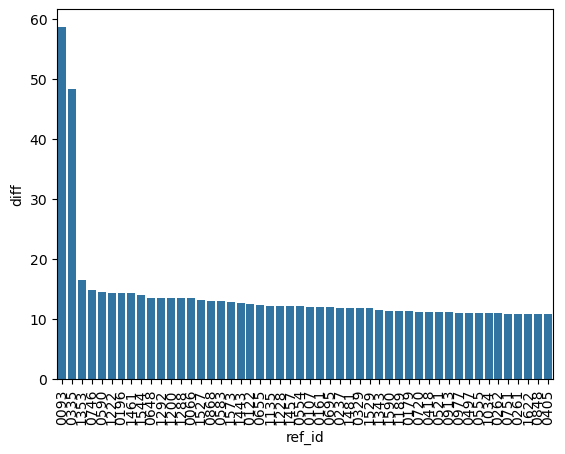

In [8]:
res_c1_diff = (
    res_c1
    .sort_values(by="diff", key=lambda s: s.abs(), ascending=False)
    .head(50)
)

p1 = sns.barplot(
    res_c1_diff,
    x='ref_id',
    y='diff'
)
plt.xticks(rotation=90, ha="center")
plt.show()

In [9]:
# coverage per position
cov_tb = (
    res_rs
      .query("pool == 'c1' and ref_id in ['0093','0335']")
      .assign(pos=lambda d: d["width"].apply(lambda w: range(1, int(w)+1)))
      .explode("pos")
      .groupby(["prot", "ref_id", "pos"], sort=False).size().rename("count").reset_index()
      .pipe(lambda d: (
          pd.MultiIndex.from_product(
              [d.prot.unique(), d.ref_id.unique(), range(1, 141)],
              names=["prot", "ref_id", "pos"]
          ).to_frame(index=False)
          .merge(d, how="left").fillna({"count": 0})
      ))
)

In [10]:
#cov_tb.to_csv(
#    f"../results/c1_diff_trunc_cov.csv", index=False
#)

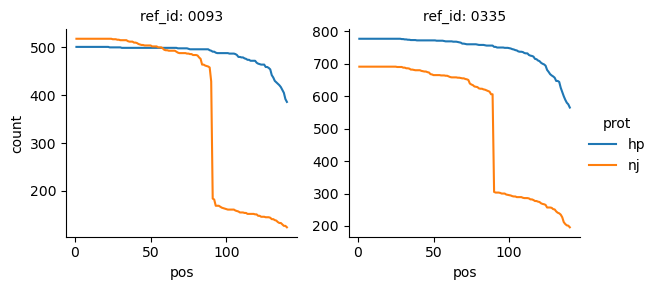

In [11]:
# plot
p2 = sns.relplot(
    cov_tb,
    x = "pos",
    y = "count",
    hue = "prot",
    col = "ref_id",
    kind = "line",
    facet_kws = dict(sharey=False),
    height=3, aspect=1
)

p2.set_titles("ref_id: {col_name}")
plt.show()

In [12]:
def largest_drop(sub):
    s = sub.sort_values("pos")["count"]
    drops = (s.shift(1) - s).fillna(0)
    idx = drops.idxmax()
    return sub.loc[idx, ["pos","count"]].rename({"pos":"drop_pos","count":"count_after"})

drop_tbl = (
    cov_tb
      .groupby(["prot", "ref_id"], sort=False)
      .apply(largest_drop, include_groups=False)
      .reset_index()
)

fa = pysam.FastaFile(ref_c1)

drop_tbl["motif"] = drop_tbl.apply(
    lambda r: fa.fetch(
        r.ref_id,
        max(r.drop_pos - 1 - 5, 0),
        r.drop_pos + 5
    ),
    axis=1
)
fa.close()

print(drop_tbl)
print('GGATG|CATCC')

  prot ref_id  drop_pos  count_after            motif
0   hp   0093       139          392        TAATTACGG
1   hp   0335       134          626   TGCTCTCCATTCTC
2   nj   0093        91          184  AGTGAGCTATCTTTA
3   nj   0335        90          305  TTGCTCACCCGGTTC
GGATG|CATCC


In [14]:
rs_dict = {
    "GGATG": re.compile(r'(GGATG){s<=5,i<=0,d<=0}'),
    "CATCC": re.compile(r'(CATCC){s<=5,i<=0,d<=0}')
}

def best_hit(seq: str):
    
    best_sub, best_pat, best_edits = None, None, 5

    for pat_name, pat in rs_dict.items():
        for m in pat.finditer(seq, overlapped=True):
            subs = m.fuzzy_counts[0]
            if subs < best_edits:
                best_sub = m.group(1)
                best_pat = pat_name
                best_edits = subs
                if best_edits == 0:
                    return best_sub, best_pat, 0
    return best_sub, best_pat, best_edits

df = (
    drop_tbl
    .query("prot == 'nj'")
    .copy()
)

df[["best_5mer", "matched_query", "edits"]] = (
    df["motif"]
      .apply(best_hit)
      .apply(pd.Series, index=["best_5mer", "matched_query", "edits"])
)

df["similarity"] = (5 - df["edits"]) / 5
df

,prot,ref_id,drop_pos,count_after,motif,best_5mer,matched_query,edits,similarity
2,nj,0093,91,184,AGTGAGCTATCTTTA,TATCT,CATCC,2,0.6
3,nj,0335,90,305,TTGCTCACCCGGTTC,CACCC,CATCC,1,0.8
